In [1]:
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.court_detector import CourtDetector
from src.utils.helpers import crop_center_img, load_process_params, lines_from_gray_img
from src.utils.filters import filter_horizontal_lines
from src.config import set_debug_mode, get_debug_mode
from cvgeomkit.utils.helpers import read_image_as_numpyimage, load_json
from cvgeomkit.utils.plotting import display_img
from cvgeomkit.geometry.intersections import compute_intersections
from cvgeomkit.geometry.lines import transform_line

In [2]:
get_debug_mode()
set_debug_mode(True)

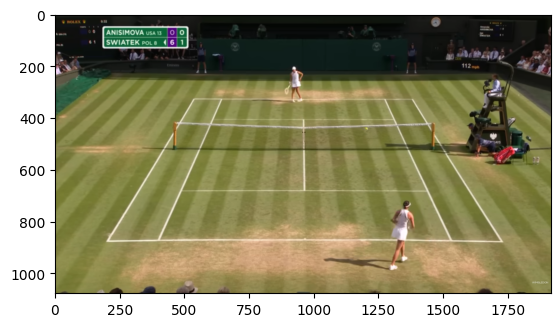

In [3]:
path = '../data/pics/07_24.png' # '../data/pics/05_10.png'     # '../data/pics/10_06.png'
# path = '../data/pics/skip/skip_01_35.png'
img = read_image_as_numpyimage(path)
display_img(img)

In [4]:
# roi = crop_center_img(img)[0][900:1000]  # [750:850]    # [900:1000]
# display_img(roi)

In [5]:
# out = cv2.bilateralFilter(roi, 15, 30, 30)
# display_img(out)

#### scan for baseline

In [6]:
params = load_process_params('../config/process_params.config.json')

crop_center_ratio = params.detection_params.basic.crop_center_ratio
roi_h_px = params.detection_params.basic.roi_h_px
step_px = params.detection_params.basic.step_px

warmup = params.detection_params.baseline.warmup
canny_lower_thresh = params.detection_params.baseline.canny_lower_thresh
canny_upper_thresh = params.detection_params.baseline.canny_upper_thresh
hough_thresh = params.detection_params.baseline.hough_thresh
min_line_len_ratio = params.detection_params.baseline.min_line_len_ratio
min_line_len_ensure_ratio = params.detection_params.baseline.min_line_len_ensure_ratio
min_line_gap_px = params.detection_params.baseline.min_line_gap_px
h_line_slope_tolerance = params.detection_params.baseline.h_line_slope_tolerance
h_delta_ensure_px = params.detection_params.baseline.h_delta_ensure_px

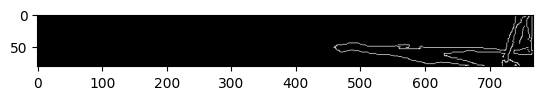

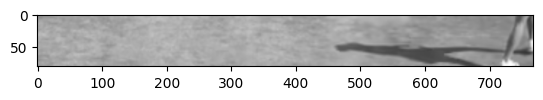

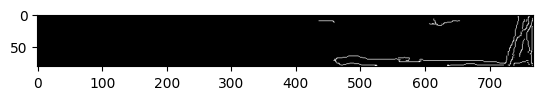

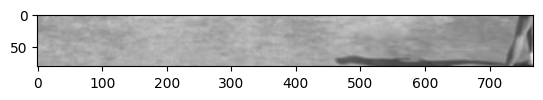

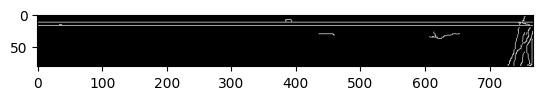

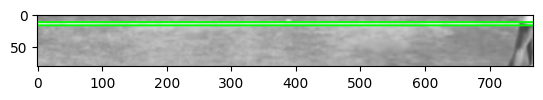

lines
[y = 0.0 * x + 17.0, y = 0.0 * x + 12.0]
baseline candidates
[y = 0.0 * x + 17.0, y = 0.0 * x + 12.0]


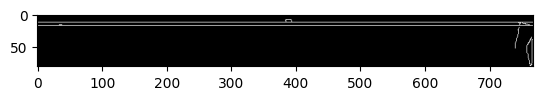

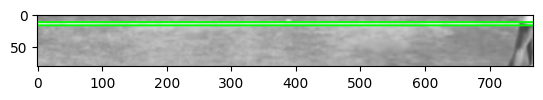

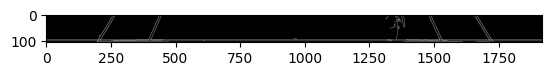

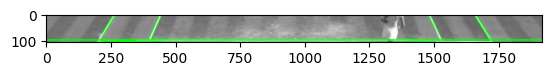

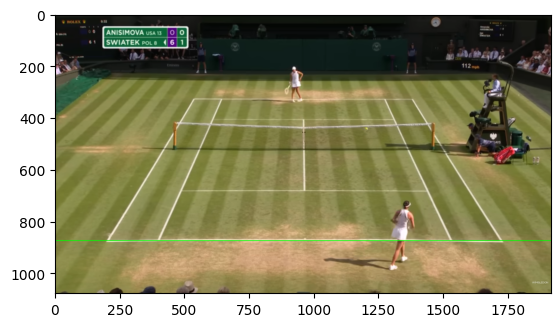

In [7]:
detector = CourtDetector(img, crop_center_ratio, roi_h_px, step_px)
baseline = detector.scan_for_baseline(
    warmup,
    canny_lower_thresh,
    canny_upper_thresh,
    hough_thresh,
    min_line_len_ratio,
    min_line_len_ensure_ratio,
    min_line_gap_px,
    h_line_slope_tolerance
)

if baseline is not None:
    p1, p2 = baseline.limit_to_img(img)
    img_copy = img.copy()
    cv2.line(img_copy, p1, p2, (0, 255, 0), 2)
    display_img(img_copy)

In [8]:
# baseline

In [9]:
delta = 100
h = 823 # int(baseline.intercept)
roi = img[h - delta:h+5] # img[h - delta:h + delta]

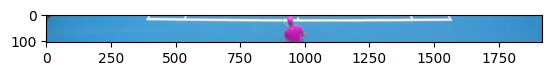

In [10]:
display_img(roi)

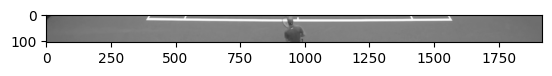

In [11]:
roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
display_img(roi_gray)

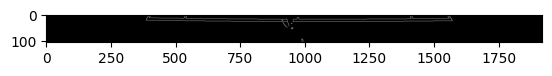

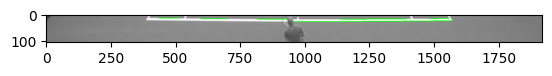

In [12]:
lines = lines_from_gray_img(
    roi_gray, 
    100,
    200,
    50,
    0.03,
    5
)
lines = filter_horizontal_lines(lines, horizontal=False)
lines_global = [transform_line(line, roi, 0, h - delta) for line in lines]

In [13]:
lines_global

[y = -0.013041210224308816 * x + 759.0]

179.25283604999575 (613, 751) y = 0.0 * x + 751.0 y = -0.013041210224308816 * x + 759.0 -0.7471639500042521 0.0


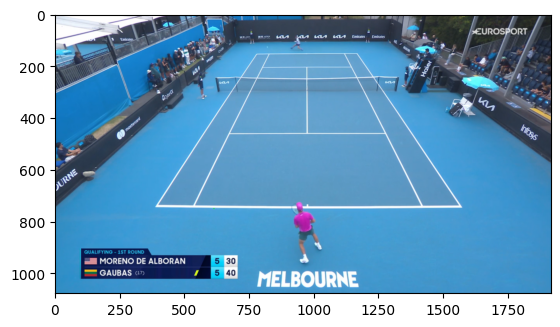

In [14]:
img_copy = img.copy()
intersections = []
for line in lines_global:
    inter = baseline.intersection(line, img)
    if inter is None:
        continue
    intersections.append(inter)
    cv2.circle(img_copy, inter.point, 2, (0, 255, 0), -1)
    print(inter.angle, inter.point, inter.line1, inter.line2, line.theta, baseline.theta)

display_img(img_copy)

In [15]:
inter_sorted = sorted(intersections, key = lambda inter: inter.point.x)
for inter in inter_sorted:
    print(inter.angle)

179.25283604999575
